### 1. Dependencies

In [136]:

import pandas as pd

import warnings
warnings.filterwarnings('ignore')


#functions
from functions.functions import low_high, set_first_row_to_zero
from functions.portfolio_strategy_design.univariate_sorting_preprocess import prepare_univariate_sorting_inputs
from functions.data_functions.get_data import get_row_universe, get_usa_universe,get_japan_universe, get_processed_fx_rates, get_snp_esg_merge_to_universe, get_refinitive_snp_merge_to_universe, get_msci_esg_merge_to_universe, get_famafrench_factors, get_processed_index, get_accounting_data
from functions.data_functions.process_data import process_row_universe, process_usa_universe, process_global_universe, process_japan_universe

In [ ]:
#Important Filters
#############################################################

golden_data = "v_2C"

region_analysis = "Japan"

# Signal Characterization
action_characterization = "4_stakeholder_new" #"dict_all_SDG_1D_prosperity_into_people, 4_stakeholder_new" # "original_matteo" # "Moji_5_signals", , dict_all_SDG_1D

esg_choice = "none"
start_year = 2012    # these ESG sources are aligned for `start_year==2013`
end_year = 2024

#Univariate Sorting Percentile Split number
no_simple_quantiles = 6


ff_factors_number = 5

signal_denominator = "Sum_All_Signals" #"Sum_All_Signals" #"Sum_All_Initiatives"


if esg_choice == "s&p":
    start_year = 2012 #USA this is 2015
    end_year = 2022


##############################


# Other Thresholds
# default: alpha_bound = 0.05
alpha_bound = 0.1    # percentage of extremes to exclude from the GOLDEN data
mktcap_covered = 0.95 # target market cap coverage per currency area # Filters bottom 5% of market cap

add_accounting_data = False

industry_level = 0 # 0 = map to larger groups, 1 = GICS_level_1, 2 = GICS_level_2

japan_year_adjustment_split_month_for_two_or_one = 3
execute_3_filters = True
min_available_fyears = 3 #was 3
min_initatives_annual_reports = 5 #was 5
drop_suspicious_gvkeys = True

#Other Initalising variables Sector Analysis
drop_real_estate = True
drop_fin = False
drop_utilities = True

drop_health_care = False
anlayse_fashion_only = False
# Keep below as weighted_average_score 
msci_score_column = "weighted"   # MSCI score column: "industry" (industry_adjusted_score) or "weighted" (weighted_average_score)


#sector split
top_x_by_industry_even_split = 6

#Filtering the GOLDEN data equally top and bottom
use_alpha_bound = True

show_sector_portfolio =  False
show_sample_portfolio = False



# Long-short spread per signal. Key = signal to build a spread for; value = direction.
#   "high_minus_low" -> long top quantile (p_n), short bottom (p_1)
#   "low_minus_high" -> long bottom (p_1), short top (p_n)
# Works for any key in `signal_quantiles` (signal_0.. and, when esg_choice is set,
# esg_refinitive / esg_sp / esg_msci). Empty dict {} = no spreads.
hml_directions = {
    "signal_0": "high_minus_low",
    "signal_1": "high_minus_low",
    "signal_2": "high_minus_low",
    "signal_3": "high_minus_low",
}






fama_factor_region = "Developed"
currency_filter = None
convert_to_USD = True


if region_analysis == "United_States":
    currency_filter = ['USD']
    region_filter = ["United States and Canada"]
    execute_region_filters = True
    convert_to_USD = False
    fama_factor_region = "United_States"
    



elif region_analysis == "North_America_and_Canada":
    currency_filter = ['USD'] 
    region_filter = ["United States and Canada"]
    execute_region_filters = True #If this is false there is rediculouly high alpha as it includes Irland and swiss
    convert_to_USD = False
    fama_factor_region = "North_America_and_Canada"
  


elif region_analysis == "Europe_and_North_America":
    #currencies we keep
    currency_filter = ['EUR', 'USD'] #['JPY'] #['CHF', 'GBP', 'EUR', 'USD'])]
    #region_filter = ["Europe", "United States and Canada"]
    convert_to_USD = True
    fama_factor_region = "Developed"
    execute_region_filters = False
    
    


    

elif region_analysis == "Europe_and_North_America_and_Japan":
    #currencies we keep
    currency_filter = ['EUR', 'USD', 'JPY'] #['JPY'] #['CHF', 'GBP', 'EUR', 'USD'])]
    
    #check JPY currency conversion (Might need to invert it)
    
    #region_filter = ["Europe", "United States and Canada"]
    convert_to_USD = True
    fama_factor_region = "Developed"
    execute_region_filters = False
    


    

elif region_analysis == "Europe":
    currency_filter = ['EUR'] #"None" for uk
    region_filter = ["Europe"]
    execute_region_filters = True 
    #Keep in local currency
    #If we dont filter by EUR
    convert_to_USD = True    #True if UK
    fama_factor_region = "Europe"
  

elif region_analysis == "Japan":
    currency_filter = ['JPY'] 
    region_filter = ["Asia-Pacific"]
    execute_region_filters = True 
    #Keep in local currency
    convert_to_USD = True
    fama_factor_region = "Japan"

In [138]:
#Golden Dataset Location
from pathlib import Path
import os

golden_location = Path(
    os.environ.get(
        "GOLDEN_LOCATION",
        Path.home() / "Documents" / "GitHub" / "data" / "Golden_Data",
    )
)

# Golden Dataset
if golden_data == "v_2C":
    lc = pd.read_csv(golden_location / "LC_dataset_v_2C_20260512.csv")
elif golden_data == "v_2B3":
    lc = pd.read_csv(golden_location / "LC_dataset_v_2B3_20260511.csv")
elif golden_data == "v_2A":
    lc = pd.read_csv(golden_location / "LC_dataset_v_2A.csv")
elif golden_data == "v_2B1":
    lc = pd.read_csv(golden_location / "LC_dataset_v_2B1_20260409.csv")




# 1. Parameters 

In [139]:
# --- Parameter summary (prints below the cell) ---
from functions.output_paths import RUN_PARAM_NAMES, format_run_parameters

_run_parameters_text = format_run_parameters(globals(), RUN_PARAM_NAMES)
print(_run_parameters_text)


=== Run parameters ===
region_analysis              = 'Japan'
action_characterization      = '4_stakeholder_new'
no_simple_quantiles          = 6
execute_3_filters            = True
golden_data                  = 'v_2C'
signal_denominator           = 'Sum_All_Signals'
esg_choice                   = 'msci'
start_year                   = 2012
end_year                     = 2024
fama_factor_region           = 'Japan'
ff_factors_number            = 5
currency_filter              = ['JPY']
convert_to_USD               = True
drop_real_estate             = True
use_alpha_bound              = True
show_sector_portfolio        = False
industry_level               = 0
min_available_fyears         = 3
top_x_by_industry_even_split = 6
alpha_bound                  = 0.1
mktcap_covered               = 0.95



Signal Design

In [140]:
from functions.signal_design.signal_definitions import dict_all_SDG_1D, dict_2d_actions_stakeholders_original_matteo,dict_4_signals_Action_1D_Pre_Nikkei, dict_4_stakeholder_signals_Pre_Nikkei, dict_all_SDG_1D_prosperity_into_people

#Choose which action characterization to use, which is dependent on function

#categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_all_SDG_1D()

if action_characterization == "original_matteo":
    categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_2d_actions_stakeholders_original_matteo()

    #What signals to include~~~
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
        "signal_2": signal_2_name,
}



elif action_characterization == "4_signals_new":
    categories_dict, signal_0_name, signal_1_name, signal_2_name, signal_3_name = dict_4_signals_Action_1D_Pre_Nikkei()
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
        "signal_2": signal_2_name,
        "signal_3": signal_3_name,
    }


elif action_characterization == "4_stakeholder_new":
    categories_dict, signal_0_name, signal_1_name, signal_2_name, signal_3_name = dict_4_stakeholder_signals_Pre_Nikkei()
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
        "signal_2": signal_2_name,
        "signal_3": signal_3_name,
    }


elif action_characterization == "dict_all_SDG_1D":
    categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_all_SDG_1D()
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
        "signal_2": signal_2_name,
    }

elif action_characterization == "dict_all_SDG_1D_prosperity_into_people":
    categories_dict, signal_0_name, signal_1_name = dict_all_SDG_1D_prosperity_into_people()
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
    }





Signal Choice

### 2. Data

In [141]:

analyse_high_low = "High"
_bucket = "high" if analyse_high_low == "High" else "low"
_all_lc_signals = [(f"signal_{i}", _bucket) for i in range(len(lc_signals))]

if esg_choice == "none":

    universe_signals = {}
    analysis_selection = _all_lc_signals



elif esg_choice == "refinitiv":
    universe_signals = {"esg_refinitive": "esg_refinitive",}
    analysis_selection = _all_lc_signals + [("esg_refinitive", "high")]
    hml_directions["esg_refinitive"] = ["high_minus_low"]
    
elif esg_choice == "s&p":
    universe_signals = {    "esg_sp": "esg_sp",}
    analysis_selection = [("esg_sp", "high"), ("esg_sp", "low")] + _all_lc_signals
    hml_directions["esg_sp"] =  ["high_minus_low"]
elif esg_choice == "msci":
    universe_signals = {"esg_msci": "esg_msci",}
    analysis_selection = _all_lc_signals + [("esg_msci", "high")]
    hml_directions["esg_msci"] = ["high_minus_low"]


#### 2.1 LC dataset

clean below

In [142]:
from functions.data_functions.process_lc import process_lc, map_sectors, filter_sum_activities_by_fiscal_year_quantiles

lc = process_lc(lc, start_year, end_year)



# Additional Filters!



if execute_3_filters:
    #1-------------Filter companies with less than 3 years of data


    from functions.data_functions.process_lc import add_available_fyears
    lc = add_available_fyears(lc)

    print(f"Before filtering companies with less than {min_available_fyears} years of data: ", lc.shape)
    lc = lc[lc["n_available_fyears"] >= min_available_fyears]
    print(f"After filtering companies with less than {min_available_fyears} years of data: ", lc.shape)



    #2-------------Filter out suspicious gvkeys

    if drop_suspicious_gvkeys:
        print("Shape before: ", lc.shape)

        lc_suspicious = pd.read_csv(golden_location / "lc_gvkey_suspicious.csv")

        print("Number of suspicious: ", lc_suspicious.shape[0])
        print(lc_suspicious["suspicious_flag"].value_counts())

        lc_suspicious["original_gvkey"] = lc_suspicious["original_gvkey"].astype(str).str.zfill(6)
        lc["gvkey"] = lc["gvkey"].astype(str).str.zfill(6)
        print("Number of suspicious that are NAN: ", lc_suspicious["suspicious_flag"].isna().sum())

        print("unique gvkeys: ", lc["gvkey"].nunique(), "Unique gvkeys in suspicious: ", lc_suspicious["original_gvkey"].nunique())
        lc = lc.merge(lc_suspicious[["original_gvkey", "suspicious_flag", "likely_reason_codes"]], left_on="gvkey", right_on="original_gvkey", how="left")
        print(lc["suspicious_flag"].value_counts())
        print("Number of suspicious that are NAN: ", lc["suspicious_flag"].isna().sum())
        lc.to_csv("./data/debug/lc_before_suspicious_filtered.csv")
        lc = lc[lc["suspicious_flag"] != True]
        print("Shape after filtering Truly Sus: ", lc.shape)


    #3-------------Filter out Annual Reports with Less tha 5 Total initaitves
    print("Before filtering Annual Reports: ", lc.shape)
    lc = lc[~((lc["n_predicted_initiatives"] < min_initatives_annual_reports) & (lc["report_type"] == "Annual Report"))]
    print("After filtering Annual Reports: ", lc.shape)



    lc.to_csv("./data/debug/lc_after_all_filter.csv")



if anlayse_fashion_only:
    lc = lc[lc['GICS_level_3'].isin(["Textiles, Apparel & Luxury Goods"])]



if drop_real_estate:
    lc = lc[lc['GICS_level_1'] != 'Real Estate']




>>>> add_missing_gvkeys: filled 0 rows
Added SREC columns:  Index(['customers', 'employees', 'environment',
       'local communities and society', 'nothing', 'shareholders',
       'suppliers'],
      dtype='object')
Before filtering companies with less than 3 years of data:  (68854, 532)
After filtering companies with less than 3 years of data:  (59977, 532)
Shape before:  (59977, 532)
Number of suspicious:  17472
suspicious_flag
False    11929
True      5543
Name: count, dtype: int64
Number of suspicious that are NAN:  0
unique gvkeys:  9259 Unique gvkeys in suspicious:  17472
suspicious_flag
False    42918
True     16673
Name: count, dtype: int64
Number of suspicious that are NAN:  386
Shape after filtering Truly Sus:  (43304, 535)
Before filtering Annual Reports:  (43304, 535)
After filtering Annual Reports:  (40512, 535)


In [143]:


if industry_level == 0:
    lc['Industry'] = lc['GICS_level_1'].apply(map_sectors)
elif industry_level == 1:
    lc['Industry'] = lc['GICS_level_1']
elif industry_level == 2:
    lc['Industry'] = lc['GICS_level_2']


if drop_fin:
    lc = lc[lc['Industry'] != 'Financial']

if drop_utilities:
    lc = lc[lc['Industry'] != 'Utilities']

if drop_health_care:
    lc = lc[lc['Industry'] != 'Health Care']

# # Filter to keep a stable panel meaning we have initiatives for all years
# gvkey_stable_panel = lc.groupby(['gvkey'])['gvkey'].count() == (lc['rfyear'].max()-lc['rfyear'].min()+1)
# gvkey_stable_panel = gvkey_stable_panel[gvkey_stable_panel].index
# lc = lc[lc['gvkey'].isin(gvkey_stable_panel)]


if execute_region_filters == True:
    lc = lc[lc["MacroRegion"].isin(region_filter)]
    if region_analysis == "United_States":
            lc = lc[lc["loc"] == "USA"]


In [144]:
for (key, value) in categories_dict.items():
    if f'sum_with_{value}' in lc.columns:
        lc[f'sum_with_{value}'] += lc[key]

    else:
        lc[f'sum_with_{value}'] = lc[key].values



if signal_denominator == "Sum_All_Signals":
    lc['sum_activities'] = lc.loc[:, list(categories_dict.keys())].sum(axis=1)
elif signal_denominator == "Sum_All_Initiatives":
    lc['sum_activities'] = lc['n_predicted_initiatives']


In [145]:
lc["sum_activities"].describe()

count    17259.000000
mean        27.785503
std         30.817751
min          0.000000
25%          9.000000
50%         18.000000
75%         35.000000
max        381.000000
Name: sum_activities, dtype: float64

In [146]:
if use_alpha_bound:

    lc = filter_sum_activities_by_fiscal_year_quantiles(
        lc,
        lower_exclude= (alpha_bound/2),
        upper_exclude= (alpha_bound/2),
    )

else:
    lower_exclude = 0.2*2
    upper_exclude = 0.05*2

    lc = filter_sum_activities_by_fiscal_year_quantiles(
        lc,
        lower_exclude= (lower_exclude/2),
        upper_exclude= (upper_exclude/2),
    )

In [147]:
lc["sum_activities"].describe()

count    15199.000000
mean        24.157905
std         19.077513
min          4.000000
25%         10.000000
50%         18.000000
75%         33.000000
max        121.000000
Name: sum_activities, dtype: float64

Create the signal

In [148]:
max_category = max(categories_dict.values())
for i in range(max_category+1):
    lc[f'signal_{i}'] = lc[f'sum_with_{i}'] / lc['sum_activities']

Num stocks in USA and EU prior to some more filters

In [149]:
lc.loc[(lc['loc'] == 'USA') | (lc['MacroRegion'] == 'Europe'), 'gvkey'].nunique()

0

#### 2.2 WRDS, Fama-French and FX data

Get and Process:
1- FX data

2- USA Universe

3- ROW Universe

4 - Japan

5 - ESG

4- Fama-French

5- Global Universe

6- Accounting Data

In [150]:
# Download from FRB H.10
# https://www.federalreserve.gov/datadownload/Output.aspx?rel=H10&series=d3efeda92e22923be9b7c3d7250706ac&lastobs=&from=01/01/2009&to=12/31/2024&filetype=csv&label=include&layout=seriescolumn
fx_rates = get_processed_fx_rates(end_year)

# Keep local-currency series for Europe/Japan analysis (no FX conversion)

usa_universe = get_usa_universe(start_year, end_year, download_wrds_data=False)
usa_universe = process_usa_universe(usa_universe)

row_universe = get_row_universe(start_year, end_year, download_wrds_data=False)
row_universe = process_row_universe(row_universe,fx_rates,convert_to_USD,)


japan_universe = get_japan_universe(start_year, end_year, download_wrds_data=False)
japan_universe = process_japan_universe(japan_universe,fx_rates,convert_to_USD,japan_year_adjustment_split_month_for_two_or_one)

# This is a shortcut for the case without ESGs
if esg_choice == 'none':
    usa_universe['esg'] = 100
    row_universe['esg'] = 100
    japan_universe['esg'] = 100

elif esg_choice != 'none':
    if esg_choice == "refinitiv":
        usa_universe, row_universe, japan_universe = get_refinitive_snp_merge_to_universe(usa_universe, row_universe, japan_universe)
    elif esg_choice == "s&p":
        usa_universe, row_universe, japan_universe = get_snp_esg_merge_to_universe(usa_universe, row_universe, japan_universe)
    elif esg_choice == "msci":
        usa_universe, row_universe, japan_universe = get_msci_esg_merge_to_universe(usa_universe, row_universe, japan_universe, score_column=msci_score_column)

fama_french = get_famafrench_factors(
    start_year,
    end_year,
    fama_factor_region,
    ff_factors_number,
    download_developed_ff_data=False,
)

global_universe = process_global_universe(usa_universe,row_universe,japan_universe,currency_filter,mktcap_covered,
    esg_choice,)

print("columns with year")
print([c for c in global_universe.columns if c == 'year' or c.startswith('year_')])

# if add_accounting_data:
#     #Note this will result in a lower sample and non-profitable stocks will be removed
#     global_universe = global_universe.drop(columns=['year_x'], errors='ignore')
#     global_universe = get_accounting_data(global_universe, region_analysis, start_year, end_year, dowload_acc_data = True)


#Ensure gvkey is 6 digits for merging
global_universe["gvkey"] = global_universe["gvkey"].astype(str).str.zfill(6)
lc["gvkey"] = lc["gvkey"].astype(str).str.zfill(6)

columns with year
['year_x', 'year_y', 'year']


In [151]:
# global_universe["gvkey"].astype(str).str.len().value_counts()   

In [152]:
# lc["gvkey"].astype(str).str.len().value_counts()   

In [153]:
lc["Industry"].unique()

array(['Industrials', 'Primary Industries', 'Health Care', 'Consumer',
       'ICT', 'Financial'], dtype=object)

### 3. Univariate Portfolio sorting

In [154]:
cols_standardization = ['rfyear', 'curcdd', 'Industry']



prep = prepare_univariate_sorting_inputs(
    global_universe=global_universe,
    lc=lc,
    fama_french=fama_french,
    lc_signals=lc_signals,
    universe_signals=universe_signals,
    category_columns=sorted(categories_dict.keys()),
    cols_standardization=cols_standardization,
    apply_geo_filter=False,
)

global_universe = prep.global_universe
global_returns  = prep.global_returns
signals         = prep.signals        # dict: column name -> (date x gvkey_iid) pivot
signal_names    = prep.signal_names   # dict: column name -> display name
signal_df       = prep.global_long_df
fama_french     = prep.fama_french




[prepare_univariate_sorting_inputs] FF rows=141 | returns rows=141
[prepare_univariate_sorting_inputs] all months match: True
     ff_date returns_date  match
0    2013-04      2013-04   True
1    2013-05      2013-05   True
2    2013-06      2013-06   True
3    2013-07      2013-07   True
4    2013-08      2013-08   True
5    2013-09      2013-09   True
6    2013-10      2013-10   True
7    2013-11      2013-11   True
8    2013-12      2013-12   True
9    2014-01      2014-01   True
10   2014-02      2014-02   True
11   2014-03      2014-03   True
12   2014-04      2014-04   True
13   2014-05      2014-05   True
14   2014-06      2014-06   True
15   2014-07      2014-07   True
16   2014-08      2014-08   True
17   2014-09      2014-09   True
18   2014-10      2014-10   True
19   2014-11      2014-11   True
20   2014-12      2014-12   True
21   2015-01      2015-01   True
22   2015-02      2015-02   True
23   2015-03      2015-03   True
24   2015-04      2015-04   True
25   2015-05    

# code to filter infinte stocks

In [155]:
# FIND ANY STOCKS THAT HAVE INF VALUES  

import numpy as np

bad_columns = set()
for df in signals.values():
    # numeric only, in case of odd dtypes
    num = df.select_dtypes(include=[np.number])
    if num.empty:
        continue
    bad_columns.update(num.columns[np.isinf(num).any(axis=0)].tolist())

bad_columns = list(bad_columns)

print("gvekys dropped due to inf values:")
print(bad_columns)


# filter these infinite values

signals = {
    name: df.drop(columns=bad_columns, errors="ignore")
    for name, df in signals.items()
}

import numpy as np
fit1 = signals['signal_0'].select_dtypes(include=["float", "float64"])
if np.isinf(fit1).sum().sum() > 0:
    print("There are inf values in the signal_0 column")

gvekys dropped due to inf values:
['015668_01W']


% Nan in accounting data

In [156]:
# if add_accounting_data:
#     #Amount of missing accounting data as a percent
#     cols = ["roa0","roa1","roa2","ros0","ros1","ros2","sales_intensity"]
#     print((100 * global_universe[cols].isna().mean()).sort_values(ascending=False))

In [157]:
# MANUAL SETTINGS (for UnivariateQuantilePortfolio in the next section)
first_conditioning_set = 0       # momentum-like strategies: increase to skip early rows
no_simple_extremes_quantiles = 1 # high and low portfolios
take_extremes = False            # if True, low / middle / high extremes only


#### 3.1 Univariate sorting

In [158]:
from functions.portfolio_strategy_design.Univariate_Portfolio import UnivariateQuantilePortfolio

signal_quantiles: dict[str, pd.DataFrame] = {}
signal_quantile_constituents: dict[str, pd.Series] = {}

for col, pivot in signals.items():
    U = UnivariateQuantilePortfolio(
        signal=pivot,
        returns=global_returns,
        n_quantiles=no_simple_quantiles,
        first_conditioning_set=first_conditioning_set,
        take_extremes=take_extremes,
        n_extremes_quantiles=no_simple_extremes_quantiles,
    )
    signal_quantiles[col] = U.compute_returns()
    signal_quantile_constituents[col] = U.get_constituents_over_time()

# 4. Sector Split

In [159]:
# Store constituents over time + compute “next-month return” by Industry


from functions.portfolio_strategy_design.Sector_Portfolio import SectorPortfolio


if show_sector_portfolio:
    # Sector portfolio is pinned to signal_2.
    global_signal_2 = signals["signal_2"]

    #Build an industry pivot aligned to global_returns  and global_signal_*
    global_industry = global_universe.pivot(index="date", columns="gvkey_iid", values="Industry")

    #This will automatically split the even_split_no stocks into the unique sectors.
    #Select the n highest ranked stocks in each industruy and build portfolios using them.
    S = SectorPortfolio(
        signal=global_signal_2,
        returns=global_returns,
        global_universe=global_universe,
        sector_split=top_x_by_industry_even_split,          # fixed N per industry
        manual_input_split=False,
        first_conditioning_set=first_conditioning_set,
        ascending=False,
    )


    #all_industry_returns = S.compute_industry_returns()
    industry_constituents = S.get_constituents_over_time()   

    #Below assumes that ALLLL INDUSTIES HAVE THE SAME NUMBER OF STOCKS!!!!!!!!
    sector_portfolio_returns = S.equal_weight_mean_return() # equal-weight across industries


In [160]:
# Add Market Portfolios
market_factor = fama_french["mktrf"]

file_path = "./data/MSCI/MSCI_World.xlsx"
MSCI = get_processed_index(file_path, global_returns) 

In [161]:
# Transform in excess returns using the risk free rate

for col in signal_quantiles:
    signal_quantiles[col] = signal_quantiles[col].sub(fama_french['rf'].values, axis=0)

MSCI_excess_returns = MSCI["return"].sub(fama_french['rf'].values, axis=0)

if show_sector_portfolio:
    sector_portfolio_returns = sector_portfolio_returns.sub(fama_french["rf"].values, axis=0)


Excess_returns_sample = (
    global_returns.mean(axis=1)
    .sub(fama_french["rf"].values, axis=0)
    .to_frame("Sample")
)

#no need for market_factor


In [162]:
# Regression inputs keep their NaN first row (ff3_regressions drops it).
# Zeroed copies are ONLY for cumulative plots / compounding.
global_returns_cum = set_first_row_to_zero(global_returns)
signal_quantiles_cum = {c: set_first_row_to_zero(df) for c, df in signal_quantiles.items()}

market_factor_cum = market_factor.copy()   # .copy() avoids mutating fama_french["mktrf"]
market_factor_cum.iloc[0] = 0

if show_sector_portfolio:
    sector_portfolio_returns_cum = sector_portfolio_returns.copy()
    sector_portfolio_returns_cum.iloc[0] = 0

# 5. Fama-French

In [163]:

if show_sector_portfolio:
    sector_portfolio_returns_df = pd.DataFrame()
    sector_portfolio_returns_df[f"Sector equal split {signal_2_name}"] = sector_portfolio_returns
    sector_portfolio_returns = sector_portfolio_returns_df

High - Low

In [164]:
# Per-signal long-short spreads, driven by `hml_directions` (set in the parameters cell).
# Build two parallel dicts keyed by the generated spread label:
#   spread_signals[label] -> raw spread (NaN first row) for FF tables + rolling FF regression
#   spread_cum[label]     -> zeroed-first-row spread for cumulative compounding/plot
# Long-short spread: rf cancels ((high-rf) - (low-rf) = high - low), so rf is NOT added back.
_hml_hi, _hml_lo = f"p_{no_simple_quantiles}", "p_1"

spread_signals: dict[str, pd.DataFrame] = {}
spread_cum: dict[str, pd.Series] = {}

for _sig, _dirs in hml_directions.items():
    if _sig not in signal_quantiles:
        raise KeyError(
            f"{_sig!r} in hml_directions not found in signal_quantiles "
            f"(available: {list(signal_quantiles)})"
        )

    # A signal may map to a single direction (str) or several (list/tuple),
    # e.g. ["high_minus_low", "low_minus_high"] to build both spreads.
    for _dir in ([_dirs] if isinstance(_dirs, str) else _dirs):
        if _dir == "high_minus_low":
            _label = f"High - Low {signal_names[_sig]}"
            _raw = signal_quantiles[_sig][_hml_hi] - signal_quantiles[_sig][_hml_lo]
            _cum = signal_quantiles_cum[_sig][_hml_hi] - signal_quantiles_cum[_sig][_hml_lo]
        elif _dir == "low_minus_high":
            _label = f"Low - High {signal_names[_sig]}"
            _raw = signal_quantiles[_sig][_hml_lo] - signal_quantiles[_sig][_hml_hi]
            _cum = signal_quantiles_cum[_sig][_hml_lo] - signal_quantiles_cum[_sig][_hml_hi]
        else:
            raise ValueError(
                f"Unknown direction {_dir!r} for {_sig}; use 'high_minus_low' or 'low_minus_high'"
            )

        spread_signals[_label] = _raw.to_frame(_label)
        spread_cum[_label] = _cum


In [165]:
#### Rolling Alpha
from functions.portfolio_metrics.fama_french import rolling_ff_alphas

# Select what you want to analyse in the rolling alpha and cumulative returns
base_analysis_selection = [(s, "high") for s in reversed(lc_signals)]
base_analysis_selection.append(("signal_0", "low"))
# base_analysis_selection.append(("signal_2", "high"))


# base_analysis_selection.remove(("signal_0", "high"))


if show_sector_portfolio:
    base_analysis_selection.append(("Sector equal split signal_2", "high"))




if esg_choice == "refinitiv":
   
    base_analysis_selection.append(("esg_refinitive", "high"))
elif esg_choice == "s&p":
    base_analysis_selection.append(("esg_sp", "high"))
elif esg_choice == "msci":
    base_analysis_selection.append(("esg_msci", "high"))
    


rolling_alpha_selection = base_analysis_selection

_valid_buckets = {"high", "low"}
_invalid_buckets = sorted({b for _, b in rolling_alpha_selection} - _valid_buckets)
if _invalid_buckets:
    raise ValueError(f"Invalid bucket(s) in analysis_selection: {_invalid_buckets}. Use 'high' or 'low'.")

_missing_signal_keys = sorted({c for c, _ in rolling_alpha_selection} - set(signal_quantiles))
if _missing_signal_keys:
    raise KeyError(f"Signal key(s) in analysis_selection not found in signal_quantiles: {_missing_signal_keys}")

_bucket_to_col    = {"high": f"p_{no_simple_quantiles}", "low": "p_1"}
_bucket_to_prefix = {"high": "High", "low": "Low"}

rolling_signals_arg = [
    {
        "label": f"{_bucket_to_prefix[bucket]} {signal_names[col]}",
        "returns": signal_quantiles[col],
        "alpha_column": _bucket_to_col[bucket],
    }
    for col, bucket in rolling_alpha_selection
]


if show_sector_portfolio:
    _sector_label = f"Sector equal split {signal_2_name}"
    rolling_signals_arg.append({
        "label": _sector_label,
        "returns": sector_portfolio_returns,
        "alpha_column": _sector_label,
    })

if show_sample_portfolio:
    _market_sample_label = f"Sample"
    rolling_signals_arg.append({
        "label": _market_sample_label,
        "returns": Excess_returns_sample,
        "alpha_column": _market_sample_label,
    })


for _label, _df in spread_signals.items():
    rolling_signals_arg.append({
        "label": _label,
        "returns": _df,
        "alpha_column": _label,
    })


try:
    rolling_alphas_window_size_40 = rolling_ff_alphas(
        signals=rolling_signals_arg,
        fama_french=fama_french,
        window_size=40,
        n_factors=ff_factors_number,
    )
except Exception as e:
    print(f"Error in rolling_ff_alphas: {e}")


rolling_alphas_window_size_24 = rolling_ff_alphas(
    signals=rolling_signals_arg,
    fama_french=fama_french,
    window_size=24,
    n_factors=ff_factors_number,
)




# 6. Performance Metrics

In [166]:
global_gross_portfolio_returns = pd.DataFrame(index=global_returns_cum.index)
if show_sample_portfolio:
    global_gross_portfolio_returns['Sample'] = 1 + global_returns_cum.mean(axis=1).sub(fama_french["rf"].values, axis=0)


global_gross_portfolio_returns["Market"] = 1 + market_factor_cum 
# Single selection shared with rolling alpha.
portfolio_selection = base_analysis_selection

for col, bucket in portfolio_selection:
    quantile_col = _bucket_to_col[bucket]
    label        = f"{_bucket_to_prefix[bucket]} {signal_names[col]}"
    global_gross_portfolio_returns[label] = 1 + signal_quantiles_cum[col][quantile_col]


if show_sector_portfolio:
    _sector_col = f"Sector equal split {signal_2_name}"
    global_gross_portfolio_returns[_sector_col] = 1 + sector_portfolio_returns_cum[_sector_col]

#global_gross_portfolio_returns["MSCI benchmark"] = 1 + MSCI_excess_returns

# Add risk free rate back for cumulative returns
non_risk_free_returns = global_gross_portfolio_returns.add(fama_french["rf"].values, axis=0)
portfolio_returns = non_risk_free_returns - 1

# Long-short spreads: rf cancels out ((high-rf) - (low-rf) = high - low),
# so append directly without adding rf back.
for _label, _series in spread_cum.items():
    portfolio_returns[_label] = _series

# Cumulative Returns Plot

In [167]:
portfolio_returns.isna().sum()

Market                     0
High customers            12
High suppliers            12
High employees            12
High communities          12
Low communities           12
High esg_msci             12
High - Low communities    12
High - Low employees      12
High - Low suppliers      12
High - Low customers      12
High - Low esg_msci       12
dtype: int64

In [168]:
from functions.portfolio_metrics.fama_french import ff3_regressions, ff5_regressions, rolling_ff_alphas

# FF3 table: every signal plus the sector portfolio.
ff3_parts = [
    low_high(
        ff3_regressions(signal_quantiles[col], fama_french.reset_index(drop=True)),
        signal_names[col],
    )
    for col in signal_quantiles
]

take_high_minus_low = True
if take_high_minus_low:
    for _label, _df in spread_signals.items():
        ff3_parts.append(ff3_regressions(_df, fama_french.reset_index(drop=True)))

if show_sector_portfolio:
    ff3_parts.append(ff3_regressions(sector_portfolio_returns, fama_french.reset_index(drop=True)))

if show_sample_portfolio:
    ff3_parts.append(ff3_regressions(Excess_returns_sample, fama_french.reset_index(drop=True)))

ff3_parts_df = pd.concat(ff3_parts, axis=1).round(2)
#ff3_parts_df.to_csv('./output/ff3_' + _{start_date}-{end_date} + '.csv')
ff3_parts_df.head()

,Low communities,High communities,Low employees,High employees,Low suppliers,High suppliers,Low customers,High customers,Low esg_msci,High esg_msci,High - Low communities,High - Low employees,High - Low suppliers,High - Low customers,High - Low esg_msci
alpha,-0.06,-0.08,-0.21,-0.01,-0.17,0.01,-0.11,-0.06,-0.12,0.12,-0.02,0.20,0.18,0.05,0.24
beta_mkt,1.15,1.07,1.10,1.15,0.98,1.17,1.16,1.06,1.05,1.20,-0.08,0.05,0.20,-0.10,0.15
beta_smb,0.06,0.24,0.20,0.09,0.28,0.03,0.20,0.23,0.29,0.01,0.18,-0.11,-0.25,0.03,-0.28
beta_hml,0.15,0.15,0.16,0.19,0.03,0.19,0.25,0.08,0.20,0.08,-0.00,0.03,0.16,-0.17,-0.12
p-value(alpha),0.68,0.61,0.23,0.95,0.30,0.93,0.51,0.68,0.39,0.39,0.90,0.27,0.35,0.75,0.14


In [169]:
from functions.portfolio_metrics.fama_french import ff3_regressions, ff5_regressions, rolling_ff_alphas

ff5_parts = [
        low_high(
            ff5_regressions(signal_quantiles[col], fama_french.reset_index(drop=True)),
            signal_names[col],
        )
        for col in signal_quantiles
    ]


take_high_minus_low = True
if take_high_minus_low:
    for _label, _df in spread_signals.items():
        ff5_parts.append(ff5_regressions(_df, fama_french.reset_index(drop=True)))

if show_sector_portfolio:
        ff5_parts.append(ff5_regressions(sector_portfolio_returns, fama_french.reset_index(drop=True)))

if show_sample_portfolio:
        ff5_parts.append(ff5_regressions(Excess_returns_sample, fama_french.reset_index(drop=True)))

ff5_parts_df = pd.concat(ff5_parts, axis=1).round(2)
    #ff5_parts_df.to_csv('./output/ff5_' + _{start_date}-{end_date} + '.csv')

ff5_parts_df.head(7)

,Low communities,High communities,Low employees,High employees,Low suppliers,High suppliers,Low customers,High customers,Low esg_msci,High esg_msci,High - Low communities,High - Low employees,High - Low suppliers,High - Low customers,High - Low esg_msci
alpha,-0.07,-0.10,-0.25,-0.01,-0.16,-0.00,-0.16,-0.04,-0.17,0.11,-0.03,0.25,0.16,0.12,0.27
beta_mkt,1.12,1.07,1.08,1.12,1.00,1.15,1.16,1.07,1.06,1.17,-0.05,0.04,0.14,-0.09,0.11
beta_smb,0.10,0.23,0.24,0.13,0.23,0.07,0.22,0.21,0.28,0.06,0.13,-0.11,-0.16,-0.01,-0.22
beta_hml,0.27,0.16,0.32,0.29,-0.09,0.32,0.38,0.00,0.26,0.23,-0.11,-0.03,0.41,-0.38,-0.03
beta_rmw,0.08,0.09,0.25,0.02,-0.08,0.12,0.31,-0.12,0.22,0.12,0.01,-0.23,0.21,-0.43,-0.10
beta_cma,-0.21,0.08,-0.14,-0.23,0.25,-0.19,0.01,0.08,0.11,-0.26,0.29,-0.09,-0.44,0.07,-0.37
p-value(alpha),0.64,0.53,0.14,0.97,0.34,0.99,0.32,0.79,0.27,0.44,0.84,0.16,0.41,0.41,0.12


In [170]:
# --- Sweep harness: persist FF tables when running under papermill ---
# No-op during normal interactive runs (sweep_mode defaults to False).
if globals().get("sweep_mode", False):
    import os, pickle
    _sweep_out = globals().get("sweep_out_dir", "./output/SWEEP")
    os.makedirs(_sweep_out, exist_ok=True)
    _rid = str(globals().get("sweep_run_id", "run"))
    _payload = {"ff3": ff3_parts_df, "ff5": ff5_parts_df}
    _fp = os.path.join(_sweep_out, f"ff_{_rid}.pkl")
    with open(_fp, "wb") as _f:
        pickle.dump(_payload, _f)
    print(f"[sweep] saved FF tables for run {_rid} -> {_fp}")


Saving run artifacts to: output/4_stakeholder_new/Japan/Sum_All_Signals/esg/msci_esg/with_filters/2013-04-2024-12_split6


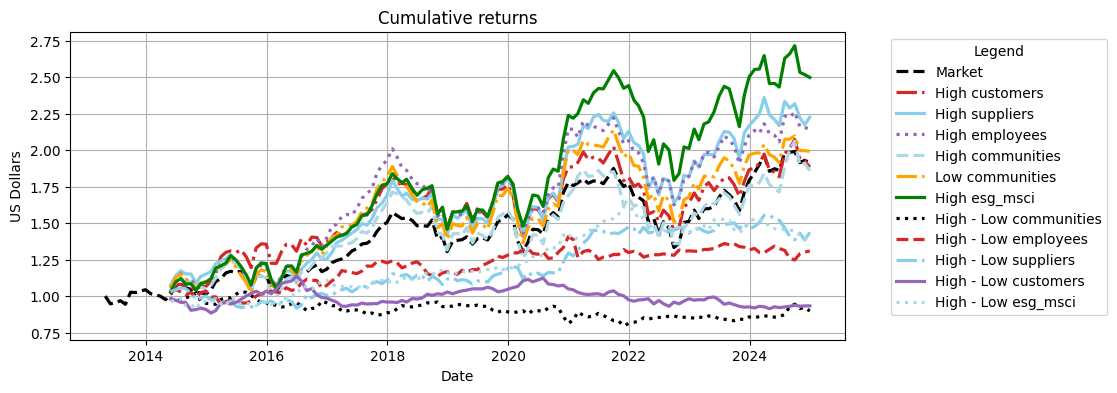

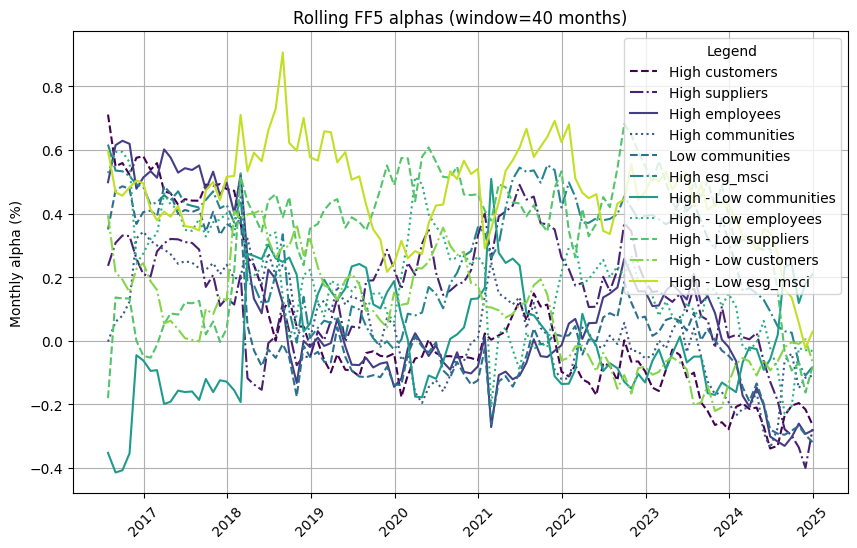

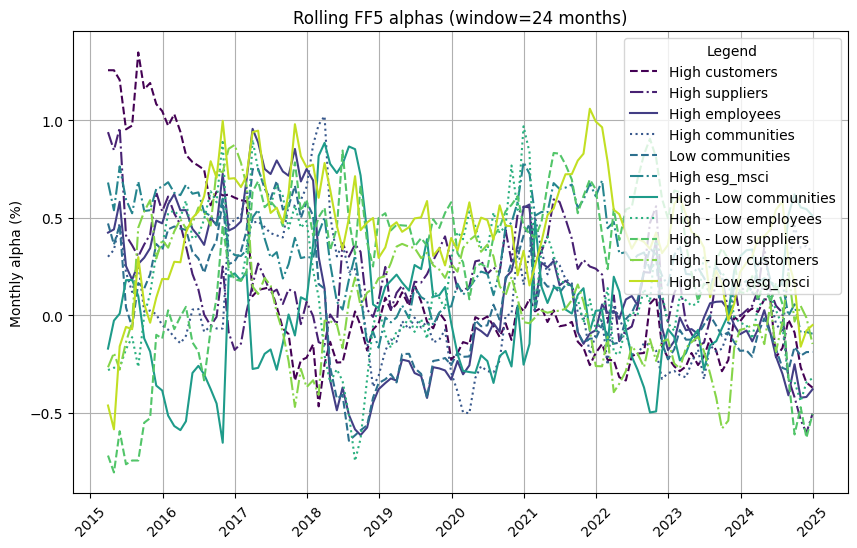

,1m,3m,YTD,1yr,3yr,5yr,10yr,Since launch
Market,-0.82%,-3.87%,6.78%,6.78%,7.93%,22.95%,88.74%,91.51%
High customers,-2.34%,-9.17%,0.87%,0.87%,3.67%,6.87%,76.65%,88.35%
High suppliers,2.40%,-3.98%,2.68%,2.68%,4.56%,23.00%,93.47%,122.69%
High employees,-0.36%,-5.06%,1.96%,1.96%,3.90%,18.43%,95.43%,114.72%
High communities,-2.73%,-9.83%,5.74%,5.74%,11.28%,17.07%,76.97%,85.98%
Low communities,-0.19%,-4.96%,1.34%,1.34%,0.66%,14.72%,81.35%,99.33%
High esg_msci,-0.78%,-8.00%,-0.16%,-0.16%,2.29%,37.20%,128.13%,149.95%
High - Low communities,-2.54%,-4.96%,4.74%,4.74%,10.61%,0.70%,-5.52%,-10.18%
High - Low employees,0.55%,4.93%,-0.58%,-0.58%,0.81%,2.18%,26.60%,30.92%
High - Low suppliers,3.77%,3.67%,-1.38%,-1.38%,-2.54%,20.76%,43.57%,43.71%


,Sharpe,VaR 1%,Max Drawdown,Alpha,p-value(alpha)
Market,0.48,-8.90%,-28.93%,,
High customers,0.47,-10.16%,-28.38%,-0.04,0.790
High suppliers,0.53,-10.22%,-27.33%,-0.00,0.990
High employees,0.52,-10.23%,-29.00%,-0.01,0.970
High communities,0.46,-9.57%,-27.15%,-0.10,0.530
Low communities,0.48,-10.03%,-29.46%,-0.07,0.640
High esg_msci,0.60,-10.55%,-29.56%,0.11,0.440
High - Low communities,-0.11,-5.34%,-22.68%,-0.03,0.840
High - Low employees,0.38,-5.22%,-11.32%,0.25,0.160
High - Low suppliers,0.46,-4.69%,-13.12%,0.16,0.410


In [171]:
import importlib
import functions.output_paths as output_paths_module
importlib.reload(output_paths_module)

from functions.portfolio_metrics.Strategy_Perfomance import StrategyPerformance
from functions.portfolio_metrics.fama_french import plot_rolling_alpha_function
from functions.output_paths import (
    output_csv_dir,
    output_images_dir,
    output_images_other_dir,
    output_run_dir,
    save_run_parameters,
)


start_date = str(portfolio_returns.index[0])[:7]
end_date = str(portfolio_returns.index[-1])[:7]

_run_dir = output_run_dir(
    action_characterization, region_analysis, signal_denominator, start_date, end_date, no_simple_quantiles,
    esg_choice=esg_choice,
    execute_3_filters=execute_3_filters,
)
_csv_dir = output_csv_dir(
    action_characterization, region_analysis, signal_denominator, start_date, end_date, no_simple_quantiles,
    esg_choice=esg_choice,
    execute_3_filters=execute_3_filters,
)
_img_dir = output_images_dir(
    action_characterization, region_analysis, signal_denominator, start_date, end_date, no_simple_quantiles,
    esg_choice=esg_choice,
    execute_3_filters=execute_3_filters,
)
_other_img_dir = output_images_other_dir(
    action_characterization, region_analysis, signal_denominator, start_date, end_date, no_simple_quantiles,
    esg_choice=esg_choice,
    execute_3_filters=execute_3_filters,
)
print(f"Saving run artifacts to: {_run_dir}")

save_run_parameters(_run_dir / "parameters.txt", globals())

ff_parts_df = ff3_parts_df if ff_factors_number == 3 else ff5_parts_df

sp = StrategyPerformance(portfolio_returns, ff3_parts_df=ff_parts_df)

_ff = fama_factor_region

_csv_dir.mkdir(parents=True, exist_ok=True)
ff_parts_df.to_csv(_csv_dir / f"ff{ff_factors_number}_regressions_ff-{_ff}.csv")

cumulative_table = sp.cumulative_performance_table(
    csv_path=_csv_dir / f"strategy_cumulative_performance_ff-{_ff}.csv")

risk_table = sp.performance_risk_metrics_table(
    csv_path=_csv_dir / f"strategy_performance_metrics_ff-{_ff}.csv")

sp.plot_cumulative_returns(
    title="Cumulative returns",
    tight_layout_rect = (0, 5, 100, 0.9),
    save_path=_img_dir / f"cumulative_returns_ff-{_ff}.png",
    csv_path=_csv_dir / f"gross_cumulative_returns_ff-{_ff}.csv",
)

# Note: sector-split alpha is appended later once `sector_portfolio_returns` exists.
try:
    plot_rolling_alpha_function(
        rolling_alphas_window_size_40,
        title=f"Rolling FF{ff_factors_number} alphas (window={40} months)",
    save_path=_img_dir / f"rolling_alphas_ff{ff_factors_number}_w{40}.png",
    csv_path=_csv_dir / f"rolling_alphas_ff{ff_factors_number}_w{40}.csv",
)
except Exception as e:
    print(f"Error in plot_rolling_alpha_function: {e}")

plot_rolling_alpha_function(
    rolling_alphas_window_size_24,
    title=f"Rolling FF{ff_factors_number} alphas (window={24} months)",
    save_path=_img_dir / f"rolling_alphas_ff{ff_factors_number}_w{24}.png",
    csv_path=_csv_dir / f"rolling_alphas_ff{ff_factors_number}_w{24}.csv",
)

display(cumulative_table)
display(risk_table)

# sp.plot_rolling_sharpe(window=40, save_path=_other_img_dir / f"strategy_rolling_sharpe_40m_ff-{_ff}.png")
#sp.plot_rolling_sharpe(window=60, save_path=_other_img_dir / f"strategy_rolling_sharpe_60m_ff-{_ff}.png")
# sp.plot_rolling_sharpe(window=24, save_path=_other_img_dir / f"strategy_rolling_sharpe_24m_ff-{_ff}.png")

# 7. Portfolio Constituents

### Portfolio constituents — category mix (`PortfolioConstituents`)

Uses `signal_2_simple_quantiles_constituents` and `global_universe` to inspect **Industry**, **`loc`**, and **MacroRegion**: line charts of stock counts over time (default = last quantile `p_k`, same as `constituents[i][-1]`) and donut charts for the **final** formation month. Optional: `analyse_all_portfolios_at_once=True` unions all `p_1`…`p_k`; `all_sub_portfolios=True` plots one subplot per quantile.


The following only inspects the high transformation

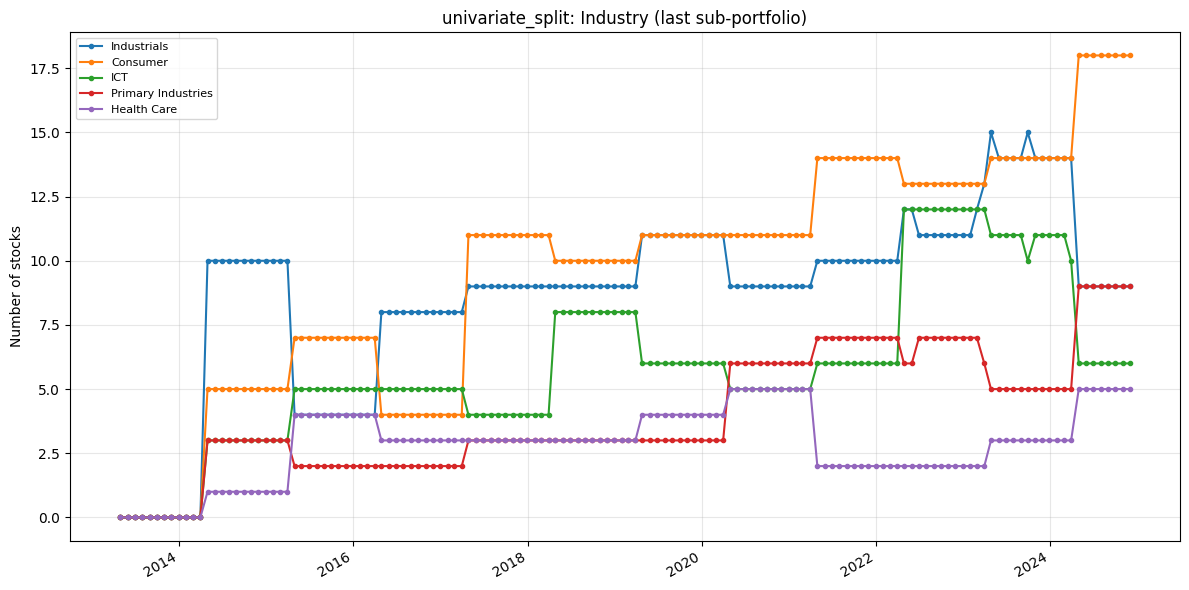

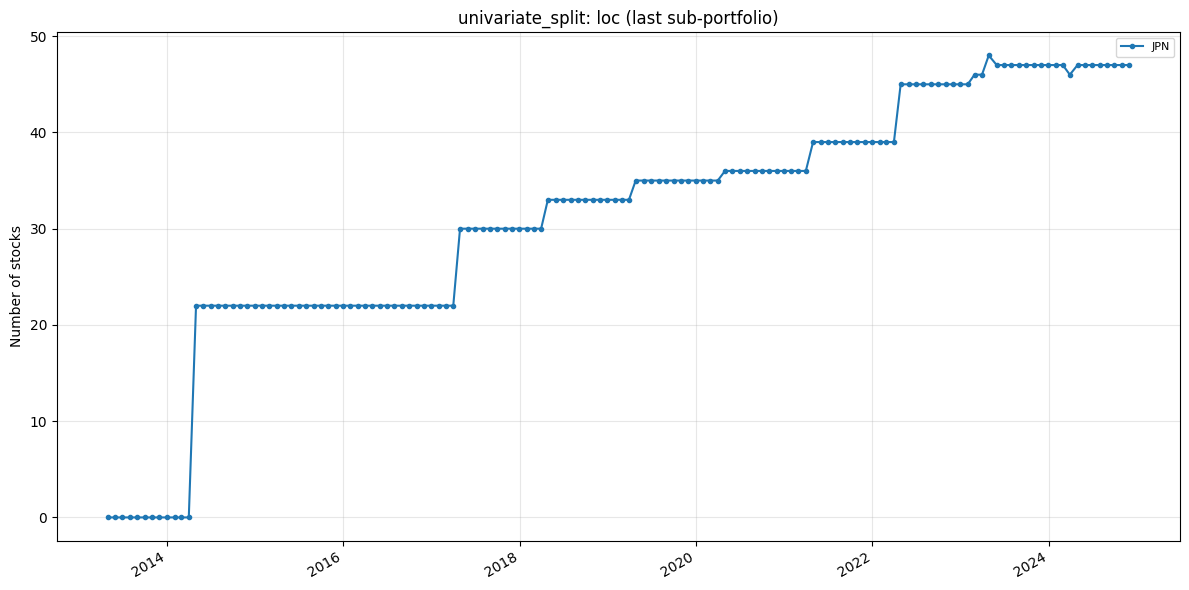

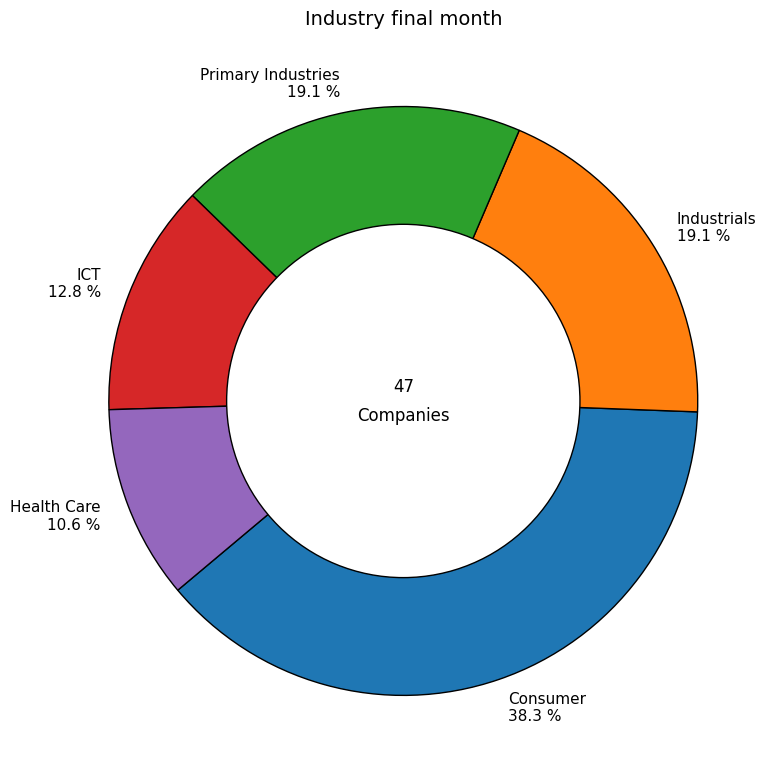

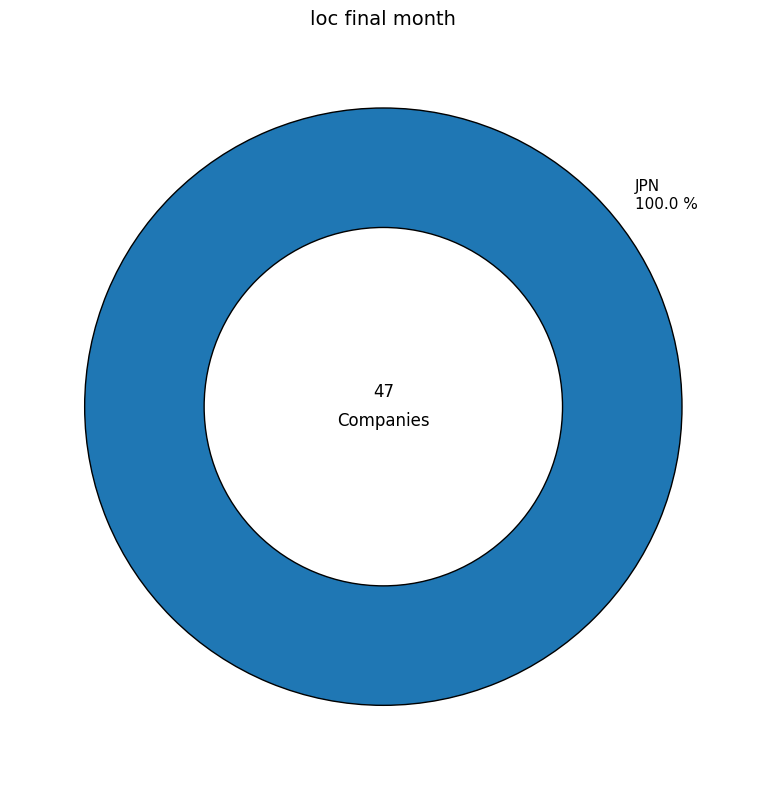

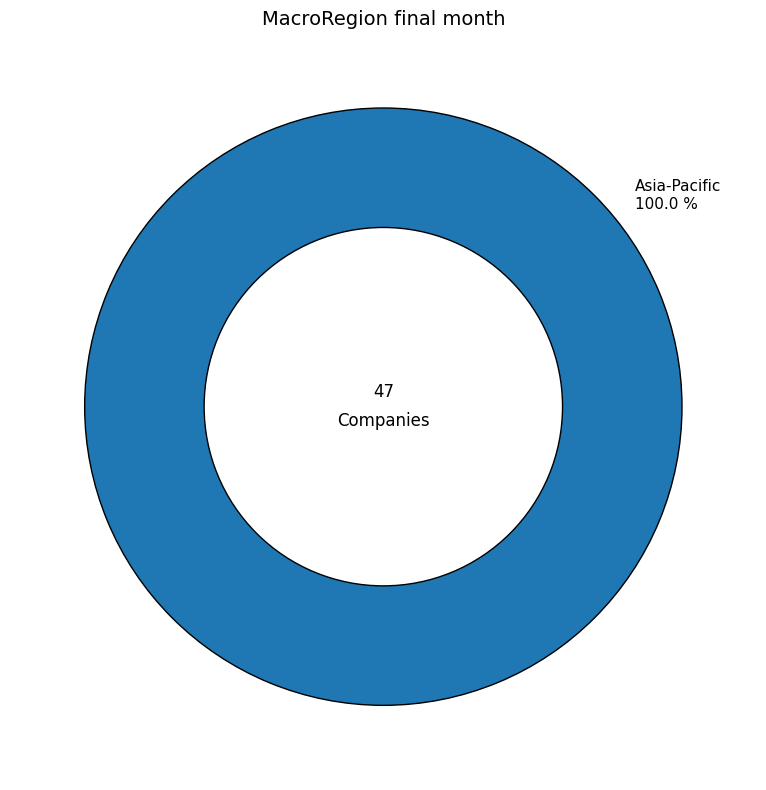

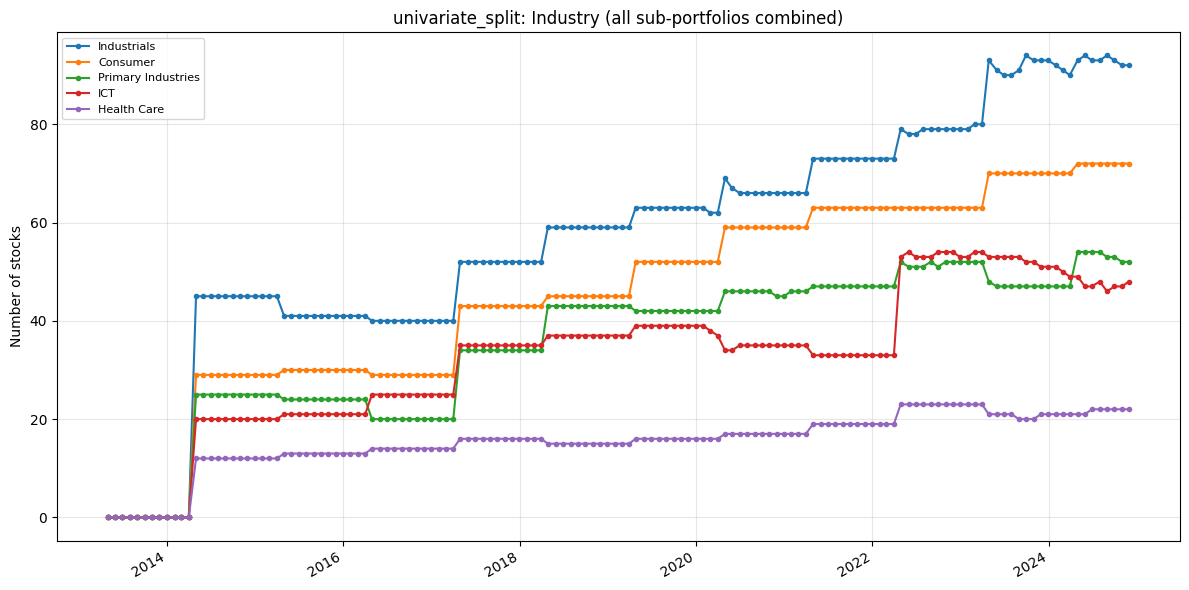

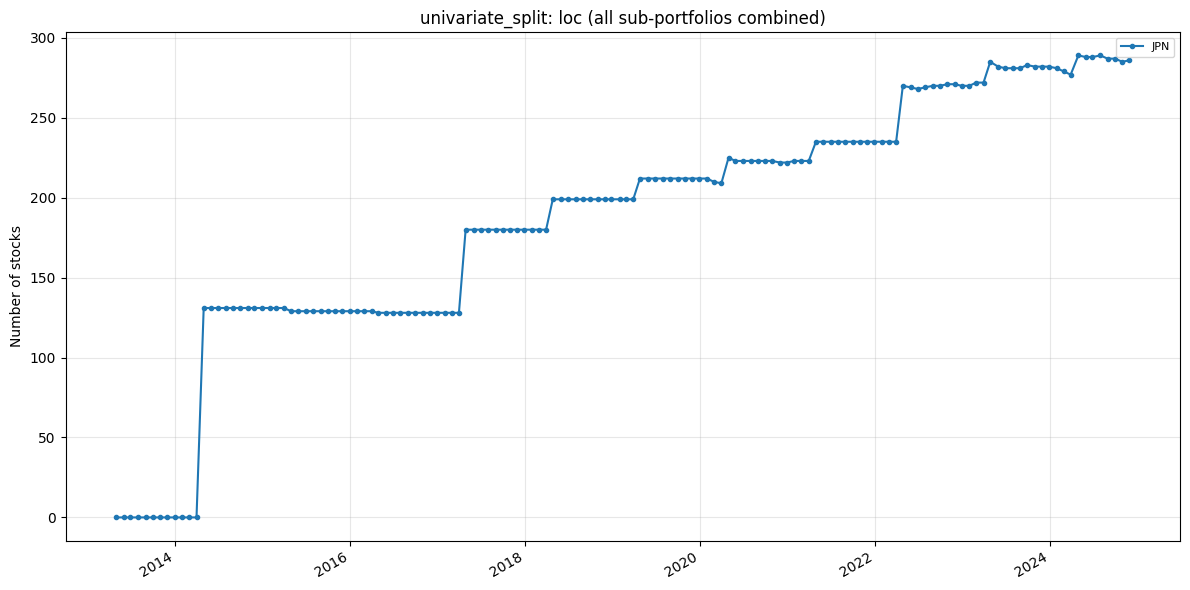

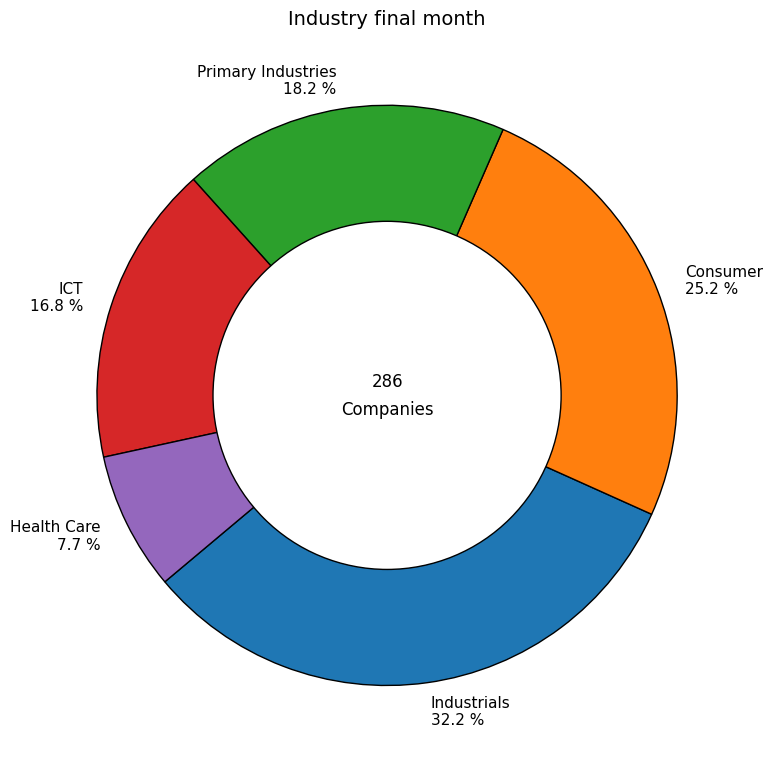

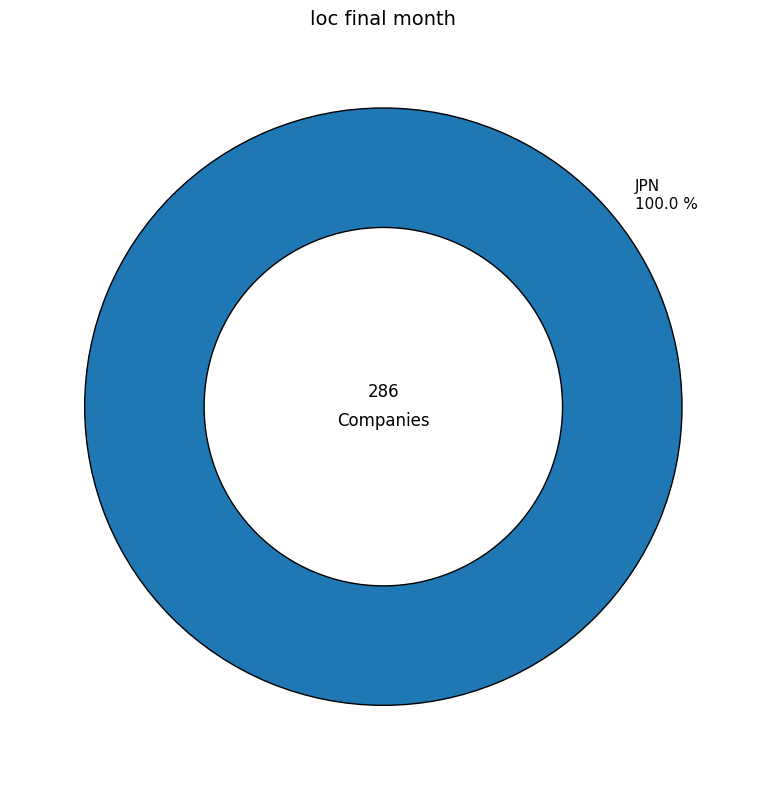

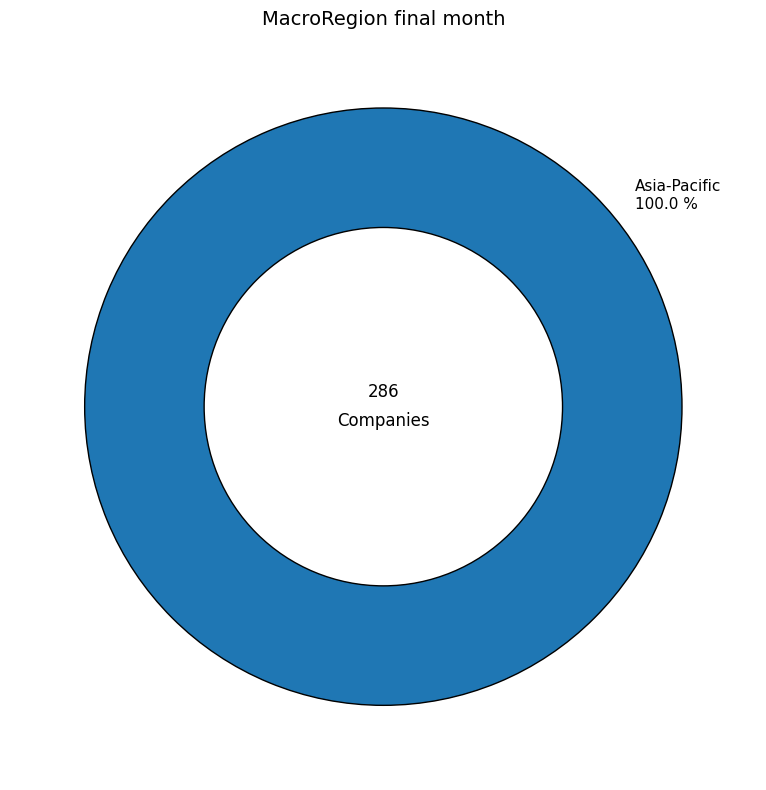

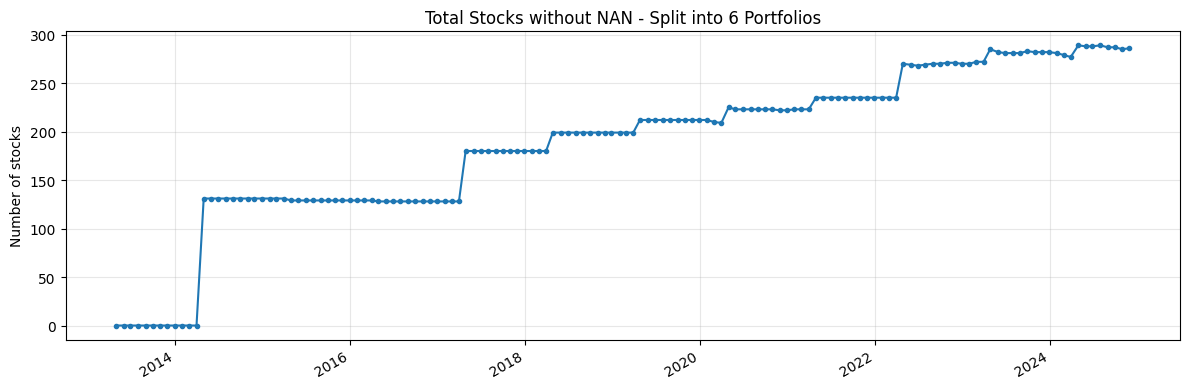

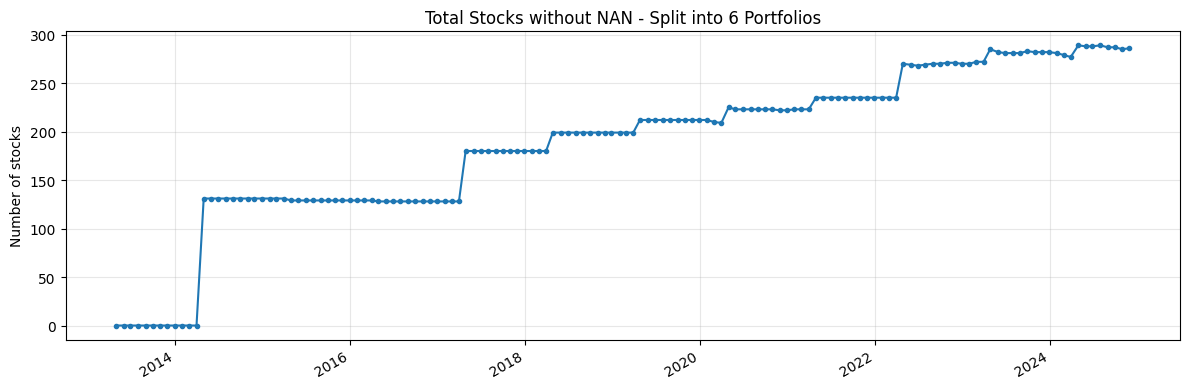

In [172]:
from IPython.display import display
from functions.portfolio_metrics.Portfolio_Constituents import PortfolioConstituents
import importlib
import functions.output_paths as output_paths_module
importlib.reload(output_paths_module)
from functions.output_paths import output_images_other_dir

# Portfolio constituents inspection is pinned to signal_2.
signal_2_simple_quantiles_constituents = signal_quantile_constituents["signal_2"]

if "start_date" not in globals() or "end_date" not in globals():
    _pc_dates = pd.to_datetime(signal_2_simple_quantiles_constituents.index)
    start_date = str(_pc_dates.min())[:7]
    end_date = str(_pc_dates.max())[:7]

_constituents_img_dir = output_images_other_dir(
    action_characterization, region_analysis, signal_denominator, start_date, end_date, no_simple_quantiles,
    esg_choice=esg_choice,
    execute_3_filters=execute_3_filters,
)

pc2 = PortfolioConstituents(
    signal_2_simple_quantiles_constituents,
    global_universe,
    portfolio_type="univariate_split",
)




_dates, wide_industry = pc2._counts_by_category_over_time(
    "Industry",
    portfolio_key=None,  # ignored when analyse_all_portfolios_at_once=True
    analyse_all_portfolios_at_once=False,
)

pc2.run_all_plots(save=True, show=True, out_dir=str(_constituents_img_dir))

# Options:
pc2.run_all_plots(
    analyse_all_portfolios_at_once=True, save=True, show=True, out_dir=str(_constituents_img_dir)
)
#pc2.run_all_plots(all_sub_portfolios=True, save=True, show=True)
# Plot (like your snippet)
pc2.total_stocks_over_time(title=f"Total Stocks without NAN - Split into {no_simple_quantiles} Portfolios")


In [173]:
# --- Parameter summary (prints below the cell) ---
from functions.output_paths import RUN_PARAM_NAMES, format_run_parameters

_run_parameters_text = format_run_parameters(globals(), RUN_PARAM_NAMES)
print(_run_parameters_text)


=== Run parameters ===
region_analysis              = 'Japan'
action_characterization      = '4_stakeholder_new'
no_simple_quantiles          = 6
execute_3_filters            = True
golden_data                  = 'v_2C'
signal_denominator           = 'Sum_All_Signals'
esg_choice                   = 'msci'
start_year                   = 2012
end_year                     = 2024
fama_factor_region           = 'Japan'
ff_factors_number            = 5
currency_filter              = ['JPY']
convert_to_USD               = True
drop_real_estate             = True
use_alpha_bound              = True
show_sector_portfolio        = False
industry_level               = 0
min_available_fyears         = 3
top_x_by_industry_even_split = 6
alpha_bound                  = 0.1
mktcap_covered               = 0.95



In [174]:
from functions.extra_functions.code_done_sound_effect import play_done_sound

play_done_sound()

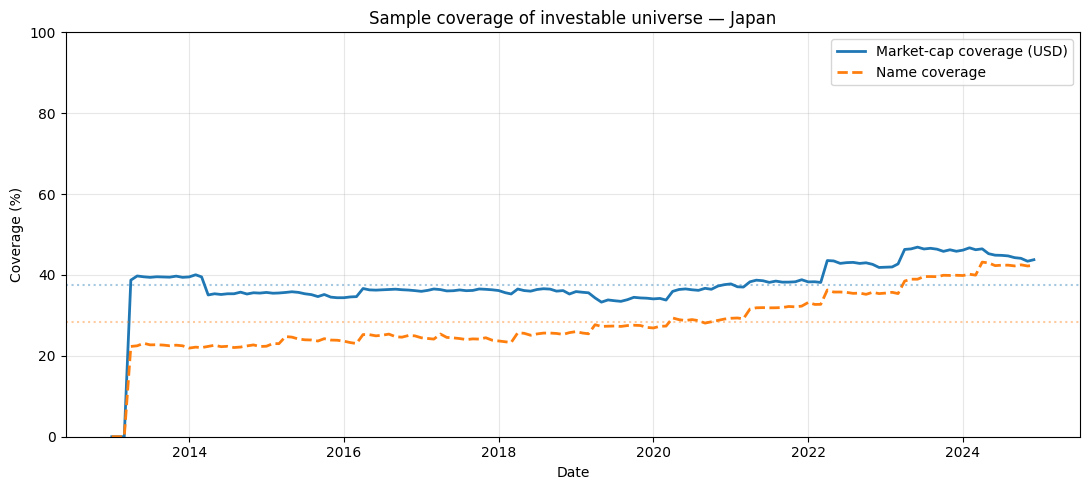

,mktcap_coverage_pct,name_coverage_pct
count,144.0,144.0
mean,37.5,28.2
std,6.7,7.5
min,0.0,0.0
25%,35.6,23.9
50%,36.5,25.7
75%,39.6,32.4
max,46.9,43.2


In [175]:
# --- Sample coverage diagnostic (isolated in functions/extra_functions/plot_coverage.py) ---
# Plots, over time, how much of the INVESTABLE UNIVERSE our analysis SAMPLE covers:
#   * market-cap coverage (computed in the run's analysis currency; never mixes currencies)
#   * name coverage
# Year-aware: a company counts only in months it actually has a signal, so the curves
# track the growing "Total Stocks without NAN" panel. Reads already-computed objects only.
import importlib
import functions.extra_functions.plot_coverage as _plot_coverage_module
importlib.reload(_plot_coverage_module)
from functions.extra_functions.plot_coverage import plot_universe_coverage_from_regions

_coverage_save = (_other_img_dir / "sample_coverage_over_time.png") if "_other_img_dir" in globals() else None

coverage_over_time = plot_universe_coverage_from_regions(
    usa_universe,
    row_universe,
    japan_universe,
    global_universe,            # post-analysis monthly sample (what entered the sorts)
    currency_filter=currency_filter,
    mktcap_covered=mktcap_covered,
    esg_choice=esg_choice,
    convert_to_USD=convert_to_USD,
    region_analysis=region_analysis,
    save_path=_coverage_save,
)

display(coverage_over_time[["mktcap_coverage_pct", "name_coverage_pct"]].describe().round(1))